### Dusty Plasma

In [ ]:
#imports
import matplotlib.pyplot as plt
import os
import numpy as np
from scipy.optimize import curve_fit

Maximale Helligkeit: 250
Positionen der maximalen Helligkeit: (array([280]), array([402]))
Maximale Spanne der y-Koordinaten: 0
x-Koordinaten der maximalen Helligkeit: [402]
Länge des Intervalls: 5


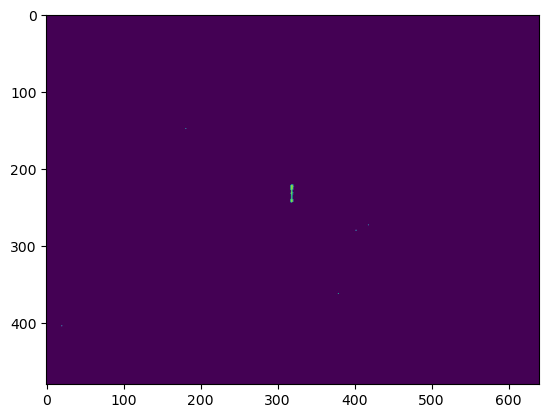

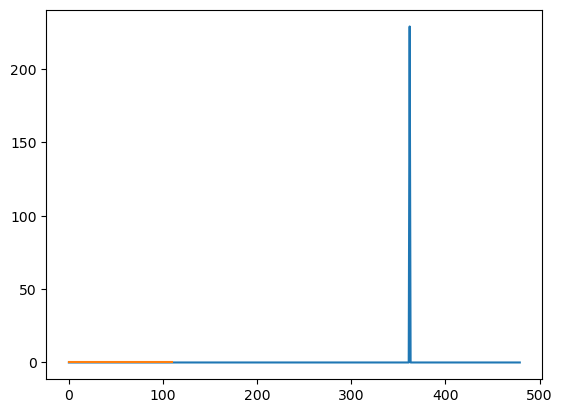

In [77]:
# öffne 2_Resonanz_20Pa4_80Vss_0000.bmp
img = plt.imread('../Messdaten/20260629_Dusty_Plasma/2_Resonanz_20Pa4_80Vss_5Vnf__0048.bmp')
plt.imshow(img)

# suche die Pixel mit der größten Helligkeit (weiß)
max_brightness = img.max()
print(f'Maximale Helligkeit: {max_brightness}')
# und ihre Positionen
max_positions = (img == max_brightness).nonzero()
print(f'Positionen der maximalen Helligkeit: {max_positions}')
# berechne die maximale Spanne der y Koordinaten der Pixel mit der größten Helligkeit
y_span = max_positions[0].max() - max_positions[0].min()    
print(f'Maximale Spanne der y-Koordinaten: {y_span}')

# integriere die Helligkeit über die x-Koordinaten in einem Intervall
x_min = 340
x_max = 390

window = img[:, x_min:x_max]
brightness_sum = window.sum(axis=1)
cropped_sum = brightness_sum[160:270]
plt.figure()
plt.plot(brightness_sum)
plt.plot(cropped_sum)

# x-Koordinate des Pixels mit der größten Helligkeit
x_max_brightness = max_positions[1]
print(f'x-Koordinaten der maximalen Helligkeit: {x_max_brightness}')
# Länge des Intervalls
interval_length = len(x_interval)
print(f'Länge des Intervalls: {interval_length}')

In [44]:
#Definition der Fitfunktionen für die Resonanzfrequenz, einmal so und einmal mit dem Hochpassfilter
def R(f, f0, R0, Gamma, offset):
    omega = 2 * np.pi * f
    omega0 = 2 * np.pi * f0
    return R0/((omega0**2-omega**2)**2 + (Gamma*omega)**2)**0.5 + offset

def RH(f, f0, R0, Gamma, offset, tau):
    omega = 2 * np.pi * f
    omega0 = 2 * np.pi * f0
    return R0/((omega0**2-omega**2)**2 + (Gamma*omega)**2)**0.5 * (omega*tau/(1+(omega*tau)**2))**0.5 + offset

Spanne 1 bei Datei 2_Resonanz_20Pa4_80Vss_5Vnf__0049.bmp wurde nicht hinzugefügt.
Maximale Spannen der y-Koordinaten: [np.int64(4), np.int64(6), np.int64(6), np.int64(4), np.int64(7), np.int64(9), np.int64(6), np.int64(7), np.int64(7), np.int64(7), np.int64(8), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(9), np.int64(9), np.int64(12), np.int64(11), np.int64(11), np.int64(12), np.int64(13), np.int64(13), np.int64(14), np.int64(13), np.int64(16), np.int64(17), np.int64(14), np.int64(15), np.int64(18), np.int64(20), np.int64(22), np.int64(23), np.int64(22), np.int64(27), np.int64(28), np.int64(30), np.int64(29), np.int64(29), np.int64(32), np.int64(31), np.int64(30), np.int64(29), np.int64(28), np.int64(28), np.int64(26), np.int64(26), np.int64(22), np.int64(22), np.int64(22), np.int64(20), np.int64(19), np.int64(18), np.int64(17), np.int64(16), np.int64(16), np.int64(17), np.int64(15), np.int64(16), np.int64(15), np.int64(13), np.int64(13), np.int64(14), np.int64(13), n

C:\Users\torbe\AppData\Local\Temp\ipykernel_16432\4193886535.py:10: RuntimeWarning: invalid value encountered in sqrt
  return R0/((omega0**2-omega**2)**2 + (Gamma*omega)**2)**0.5 * (omega*tau/(1+(omega*tau)**2))**0.5 + offset


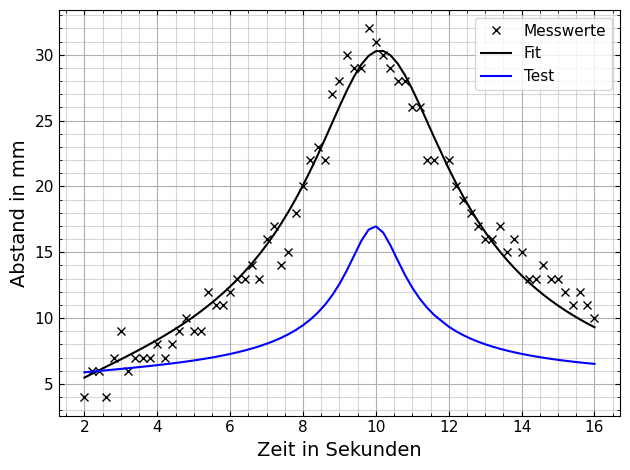

In [ ]:
# alle Dateien in 20260629_Dusty_Plasma mit 2_Resonanz_20Pa4_80Vss_5Vnf__ durchgehen und für jedes Bild die Pixel maximaler Helligkeit bestimmen und die maximale Spanne der y-Koordinaten berechnen
# jeweils die maximale Spanne der y-Koordinaten in eine Liste speichern und am Ende die Liste ausgeben
y_spans, freq = [], []
x_min, x_max = 320, 390
for filename in os.listdir('../Messdaten/20260629_Dusty_Plasma/'):
    if filename.startswith('2_Resonanz_20Pa4_80Vss_5Vnf_') and filename.endswith('.bmp'):
        img = plt.imread(f'../Messdaten/20260629_Dusty_Plasma/{filename}')
        number = int(filename.split('__')[-1].split('.')[0])
        window = img[:, x_min:x_max]
        brightness_sum = window.sum(axis=1)
        cropped_sum = brightness_sum[160:270]
        threshold = cropped_sum.mean() + 0.5 * cropped_sum.std()  # Setze den Schwellenwert auf den Mittelwert plus 0,5 Standardabweichung
        above_threshold = cropped_sum > threshold
        x_interval = (above_threshold).nonzero()[0]
        if len(x_interval) > 0:
            y_span = x_interval.max() - x_interval.min()
        else:
            y_span = 0
        if number == 0 or abs(y_span-y_spans[-1]) < 10:  # Ausreißer weg
            y_spans.append(y_span)
            freq.append(2 + number * 0.2)  # Frequenz berechnen und hinzufügen
        else: print(f'Spanne {y_span} bei Datei {filename} wurde nicht hinzugefügt.')
print(f'Maximale Spannen der y-Koordinaten: {y_spans}')
#erstellen einer Frequenzachse für die x-Achse
frequencies = np.array(freq)

#Fit der Messwerte mit der Resonanzfunktion
p0 = [10, 300000, 10, 5, 0.00001]  # Startwerte für die Parameter f0, R0, Gamma, offset, tau
popt, pcov = curve_fit(RH, frequencies, y_spans, p0)
f0, R0, Gamma, offset, tau = popt
print(f'Fitparameter: f0={f0}, R0={R0}, Gamma={Gamma}, offset={offset}, tau={tau}')

fig, ax = plt.subplots()
ax.plot(frequencies, y_spans, "xk", label="Messwerte")
ax.plot(frequencies, RH(frequencies, *popt), "-k", label="Fit")
ax.plot(frequencies, RH(frequencies, *p0), "-b", label="Test")
ax.set_xlabel("Frequenz in Hz", fontsize=14)
ax.set_ylabel("Amplitude in px", fontsize=14)
ax.tick_params(axis="both", which="both", labelsize=11, direction="in", top=True, right=True)
ax.minorticks_on()
ax.grid(which="major")
ax.grid(which="minor", alpha=0.5)
ax.legend(fontsize=11)
#ax.set_title(plottitle, fontsize=14)
fig.tight_layout()
plt.show()


Spanne 73 bei Datei 2_Resonanz_20Pa4_80Vss__0091.bmp wurde nicht hinzugefügt.
Maximale Spannen der y-Koordinaten: [np.int64(11), np.int64(11), np.int64(10), np.int64(11), np.int64(10), np.int64(10), np.int64(12), np.int64(10), np.int64(11), np.int64(12), np.int64(11), np.int64(14), np.int64(14), np.int64(14), np.int64(14), np.int64(15), np.int64(13), np.int64(16), np.int64(13), np.int64(16), np.int64(15), np.int64(16), np.int64(16), np.int64(15), np.int64(18), np.int64(18), np.int64(20), np.int64(20), np.int64(20), np.int64(20), np.int64(20), np.int64(15), np.int64(23), np.int64(15), np.int64(23), np.int64(23), np.int64(25), np.int64(27), np.int64(27), np.int64(24), np.int64(26), np.int64(28), np.int64(31), np.int64(30), np.int64(29), np.int64(35), np.int64(35), np.int64(34), np.int64(38), np.int64(39), np.int64(40), np.int64(43), np.int64(43), np.int64(45), np.int64(46), np.int64(46), np.int64(49), np.int64(52), np.int64(52), np.int64(53), np.int64(53), np.int64(55), np.int64(56), np.

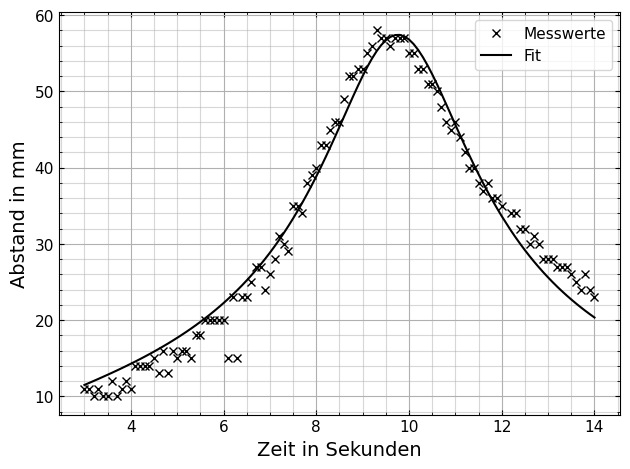

In [ ]:
# jetzt für 80Vss_10Vnf
y_spans, freq = [], []
x_min, x_max = 320, 380
for filename in os.listdir('../Messdaten/20260629_Dusty_Plasma/'):
    if filename.startswith('2_Resonanz_20Pa4_80Vss__') and filename.endswith('.bmp'):
        img = plt.imread(f'../Messdaten/20260629_Dusty_Plasma/{filename}')
        number = int(filename.split('__')[1].split('.')[0])
        window = img[:, x_min:x_max]
        brightness_sum = window.sum(axis=1)
        cropped_sum = brightness_sum[160:270]
        threshold = cropped_sum.mean() + 0.5 * cropped_sum.std()  # Setze den Schwellenwert auf den Mittelwert plus 0,5 Standardabweichung
        above_threshold = cropped_sum > threshold
        x_interval = (above_threshold).nonzero()[0]
        if len(x_interval) > 0:
            y_span = x_interval.max() - x_interval.min()
        else:
            y_span = 0
        if number == 0 or abs(y_span-y_spans[-1]) < 10:  # Ausreißer weg
            y_spans.append(y_span)
            freq.append(3 + number * 0.1)  # Frequenz berechnen und hinzufügen
        else: print(f'Spanne {y_span} bei Datei {filename} wurde nicht hinzugefügt.')
print(f'Maximale Spannen der y-Koordinaten: {y_spans}')
#erstellen einer Frequenzachse für die x-Achse
frequencies = np.array(freq)

#Fit der Messwerte mit der Resonanzfunktion
p0 = [10, 300000, 10, 10, 0.001]  # Startwerte für die Parameter f0, R0, Gamma, offset, tau
pbounds = ([0, 0, 0, 0, 0], [np.inf, np.inf, np.inf, np.inf, np.inf])  # Grenzen für die Parameter
popt, pcov = curve_fit(RH, frequencies, y_spans, p0, bounds=pbounds)
f0, R0, Gamma, offset, tau = popt
print(f'Fitparameter: f0={f0}, R0={R0}, Gamma={Gamma}, offset={offset}, tau={tau}')

fig, ax = plt.subplots()
ax.plot(frequencies, y_spans, "xk", label="Messwerte")
ax.plot(frequencies, RH(frequencies, *popt), "-k", label="Fit")
#ax.plot(frequencies, RH(frequencies, *p0), "-b", label="Test")
ax.set_xlabel("Frequenz in Hz", fontsize=14)
ax.set_ylabel("Amplitude in px", fontsize=14)
ax.tick_params(axis="both", which="both", labelsize=11, direction="in", top=True, right=True)
ax.minorticks_on()
ax.grid(which="major")
ax.grid(which="minor", alpha=0.5)
ax.legend(fontsize=11)
#ax.set_title(plottitle, fontsize=14)
fig.tight_layout()
plt.show()


Spanne 0 bei Datei 2_Resonanz_20Pa4_160Vss_5Vnf__0033.bmp wurde nicht hinzugefügt.
Maximale Spannen der y-Koordinaten: [np.int64(9), np.int64(5), np.int64(8), np.int64(6), np.int64(6), np.int64(6), np.int64(7), np.int64(6), np.int64(9), np.int64(7), np.int64(8), np.int64(8), np.int64(8), np.int64(9), np.int64(9), np.int64(10), np.int64(12), np.int64(13), np.int64(14), np.int64(16), np.int64(18), np.int64(19), np.int64(21), np.int64(20), np.int64(18), np.int64(16), np.int64(14), np.int64(13), np.int64(12), np.int64(11), np.int64(11), np.int64(8), np.int64(8), np.int64(9), np.int64(7), np.int64(7), np.int64(7), np.int64(7), np.int64(7), np.int64(5)]
Fitparameter: f0=18.153556036978834, R0=65257.064287273446, Gamma=19.39021711535319, offset=3.7901167759026286, tau=0.003254693684928872


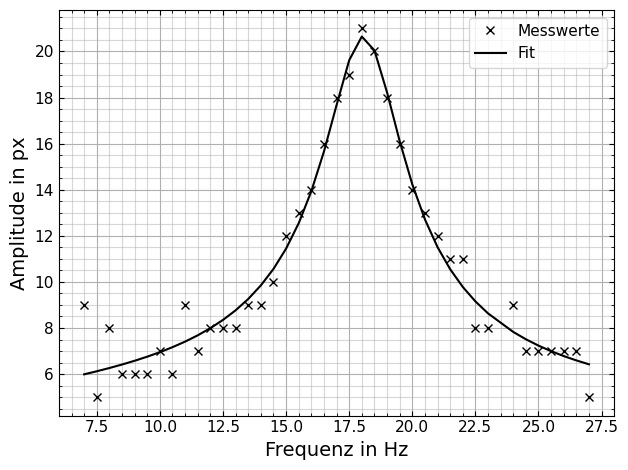

In [137]:
# jetzt für 160Vss_5Vnf
y_spans, freq = [], []
x_min, x_max = 300, 400
for filename in os.listdir('../Messdaten/20260629_Dusty_Plasma/'):
    if filename.startswith('2_Resonanz_20Pa4_160Vss_5Vnf__') and filename.endswith('.bmp'):
        img = plt.imread(f'../Messdaten/20260629_Dusty_Plasma/{filename}')
        number = int(filename.split('__')[1].split('.')[0])
        window = img[:, x_min:x_max]
        brightness_sum = window.sum(axis=1)
        cropped_sum = brightness_sum[290:390]
        threshold = cropped_sum.mean() + 0.5 * cropped_sum.std()  # Setze den Schwellenwert auf den Mittelwert plus 0,5 Standardabweichung
        above_threshold = cropped_sum > threshold
        x_interval = (above_threshold).nonzero()[0]
        if len(x_interval) > 0:
            y_span = x_interval.max() - x_interval.min()
        else:
            y_span = 0
        if number < 3 or abs(y_span-y_spans[-1]) < 40 and y_span != 0:  # Ausreißer weg
            y_spans.append(y_span)
            freq.append(7 + number * 0.5)  # Frequenz berechnen und hinzufügen
        else: print(f'Spanne {y_span} bei Datei {filename} wurde nicht hinzugefügt.')
print(f'Maximale Spannen der y-Koordinaten: {y_spans}')
#erstellen einer Frequenzachse für die x-Achse
frequencies = np.array(freq)

#Fit der Messwerte mit der Resonanzfunktion
p0 = [10, 300000, 10, 10, 0.001]  # Startwerte für die Parameter f0, R0, Gamma, offset, tau
pbounds = ([0, 0, 0, 0, 0], [np.inf, np.inf, np.inf, np.inf, np.inf])  # Grenzen für die Parameter
popt, pcov = curve_fit(RH, frequencies, y_spans, p0, bounds=pbounds)
f0, R0, Gamma, offset, tau = popt
print(f'Fitparameter: f0={f0}, R0={R0}, Gamma={Gamma}, offset={offset}, tau={tau}')

fig, ax = plt.subplots()
ax.plot(frequencies, y_spans, "xk", label="Messwerte")
ax.plot(frequencies, RH(frequencies, *popt), "-k", label="Fit")
#ax.plot(frequencies, RH(frequencies, *p0), "-b", label="Test")
ax.set_xlabel("Frequenz in Hz", fontsize=14)
ax.set_ylabel("Amplitude in px", fontsize=14)
ax.tick_params(axis="both", which="both", labelsize=11, direction="in", top=True, right=True)
ax.minorticks_on()
ax.grid(which="major")
ax.grid(which="minor", alpha=0.5)
ax.legend(fontsize=11)
#ax.set_title(plottitle, fontsize=14)
fig.tight_layout()
plt.show()

Spanne 0 bei Datei 2_Resonanz_20Pa4_160Vss__0008.bmp wurde nicht hinzugefügt.
Spanne 0 bei Datei 2_Resonanz_20Pa4_160Vss__0015.bmp wurde nicht hinzugefügt.
Spanne 0 bei Datei 2_Resonanz_20Pa4_160Vss__0021.bmp wurde nicht hinzugefügt.
Spanne 0 bei Datei 2_Resonanz_20Pa4_160Vss__0025.bmp wurde nicht hinzugefügt.
Maximale Spannen der y-Koordinaten: [np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(8), np.int64(9), np.int64(10), np.int64(8), np.int64(8), np.int64(10), np.int64(13), np.int64(24), np.int64(14), np.int64(15), np.int64(21), np.int64(23), np.int64(25), np.int64(30), np.int64(37), np.int64(37), np.int64(37), np.int64(32), np.int64(24), np.int64(24), np.int64(20), np.int64(17), np.int64(16), np.int64(15), np.int64(14), np.int64(14), np.int64(14), np.int64(12), np.int64(8), np.int64(11), np.int64(10), np.int64(11), np.int64(9)]
Fitparameter: f0=17.995161064277173, R0=2393558.8252285607, Gamma=23.24382767470568, offset=1.3310797917181556, tau=1.4299775201485369e-05


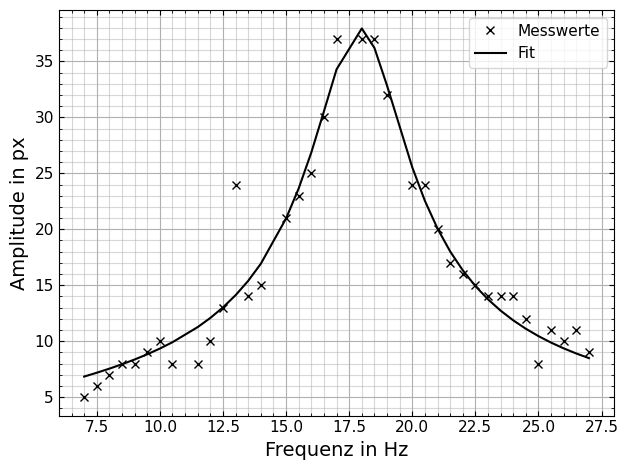

In [142]:
# jetzt für 160Vss_10Vnf
y_spans, freq = [], []
x_min, x_max = 320, 370
for filename in os.listdir('../Messdaten/20260629_Dusty_Plasma/'):
    if filename.startswith('2_Resonanz_20Pa4_160Vss__') and filename.endswith('.bmp'):
        img = plt.imread(f'../Messdaten/20260629_Dusty_Plasma/{filename}')
        number = int(filename.split('__')[1].split('.')[0])
        window = img[:, x_min:x_max]
        brightness_sum = window.sum(axis=1)
        cropped_sum = brightness_sum[290:390]
        threshold = cropped_sum.mean() + 0.5 * cropped_sum.std()  # Setze den Schwellenwert auf den Mittelwert plus 0,5 Standardabweichung
        above_threshold = cropped_sum > threshold
        x_interval = (above_threshold).nonzero()[0]
        if len(x_interval) > 0:
            y_span = x_interval.max() - x_interval.min()
        else:
            y_span = 0
        if number < 3 or abs(y_span-y_spans[-1]) < 40 and y_span != 0:  # Ausreißer weg
            y_spans.append(y_span)
            freq.append(7 + number * 0.5)  # Frequenz berechnen und hinzufügen
        else: print(f'Spanne {y_span} bei Datei {filename} wurde nicht hinzugefügt.')
print(f'Maximale Spannen der y-Koordinaten: {y_spans}')
#erstellen einer Frequenzachse für die x-Achse
frequencies = np.array(freq)

#Fit der Messwerte mit der Resonanzfunktion
p0 = [10, 300000, 10, 10, 0.001]  # Startwerte für die Parameter f0, R0, Gamma, offset, tau
pbounds = ([0, 0, 0, 0, 0], [np.inf, np.inf, np.inf, np.inf, np.inf])  # Grenzen für die Parameter
popt, pcov = curve_fit(RH, frequencies, y_spans, p0, bounds=pbounds)
f0, R0, Gamma, offset, tau = popt
print(f'Fitparameter: f0={f0}, R0={R0}, Gamma={Gamma}, offset={offset}, tau={tau}')

fig, ax = plt.subplots()
ax.plot(frequencies, y_spans, "xk", label="Messwerte")
ax.plot(frequencies, RH(frequencies, *popt), "-k", label="Fit")
#ax.plot(frequencies, RH(frequencies, *p0), "-b", label="Test")
ax.set_xlabel("Frequenz in Hz", fontsize=14)
ax.set_ylabel("Amplitude in px", fontsize=14)
ax.tick_params(axis="both", which="both", labelsize=11, direction="in", top=True, right=True)
ax.minorticks_on()
ax.grid(which="major")
ax.grid(which="minor", alpha=0.5)
ax.legend(fontsize=11)
#ax.set_title(plottitle, fontsize=14)
fig.tight_layout()
plt.show()

Spanne 15 bei Datei 2_Resonanz_34Pa_160Vss_10Vnf__0044.bmp wurde nicht hinzugefügt.
Maximale Spannen der y-Koordinaten: [np.int64(8), np.int64(10), np.int64(7), np.int64(9), np.int64(8), np.int64(10), np.int64(8), np.int64(10), np.int64(9), np.int64(10), np.int64(10), np.int64(10), np.int64(11), np.int64(12), np.int64(11), np.int64(11), np.int64(12), np.int64(12), np.int64(12), np.int64(13), np.int64(13), np.int64(13), np.int64(14), np.int64(14), np.int64(14), np.int64(15), np.int64(14), np.int64(16), np.int64(16), np.int64(16), np.int64(19), np.int64(18), np.int64(18), np.int64(19), np.int64(22), np.int64(21), np.int64(22), np.int64(22), np.int64(22), np.int64(23), np.int64(22), np.int64(22), np.int64(22), np.int64(22), np.int64(22), np.int64(22), np.int64(20), np.int64(19), np.int64(20), np.int64(19), np.int64(19), np.int64(17), np.int64(18), np.int64(18), np.int64(16), np.int64(16), np.int64(16), np.int64(14), np.int64(14), np.int64(14), np.int64(13), np.int64(15), np.int64(13), np.

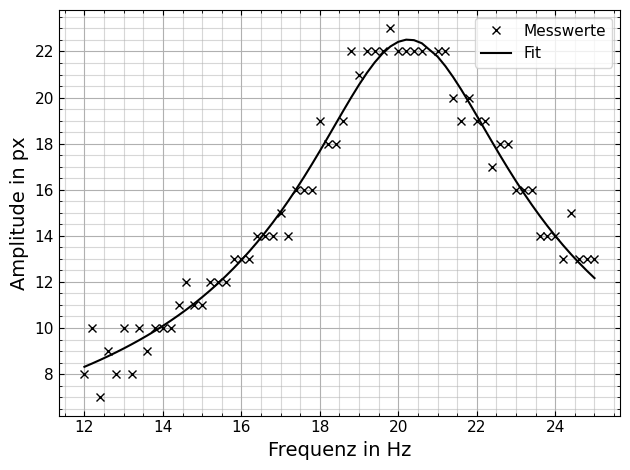

In [151]:
# jetzt für 34Pa_160Vss_10Vnf__ 12 + i * 0.2
y_spans, freq = [], []
x_min, x_max = 220, 370
for filename in os.listdir('../Messdaten/20260629_Dusty_Plasma/'):
    if filename.startswith('2_Resonanz_34Pa_160Vss_10Vnf__') and filename.endswith('.bmp'):
        img = plt.imread(f'../Messdaten/20260629_Dusty_Plasma/{filename}')
        number = int(filename.split('__')[1].split('.')[0])
        window = img[:, x_min:x_max]
        brightness_sum = window.sum(axis=1)
        cropped_sum = brightness_sum[290:390]
        threshold = cropped_sum.mean() + 0.5 * cropped_sum.std()  # Setze den Schwellenwert auf den Mittelwert plus 0,5 Standardabweichung
        above_threshold = cropped_sum > threshold
        x_interval = (above_threshold).nonzero()[0]
        if len(x_interval) > 0:
            y_span = x_interval.max() - x_interval.min()
        else:
            y_span = 0
        if number < 3 or abs(y_span-y_spans[-1]) < 7 and y_span != 0:  # Ausreißer weg
            y_spans.append(y_span)
            freq.append(12 + number * 0.2)  # Frequenz berechnen und hinzufügen
        else: print(f'Spanne {y_span} bei Datei {filename} wurde nicht hinzugefügt.')
print(f'Maximale Spannen der y-Koordinaten: {y_spans}')
#erstellen einer Frequenzachse für die x-Achse
frequencies = np.array(freq)

#Fit der Messwerte mit der Resonanzfunktion
p0 = [20, 300000, 10, 10, 0.001]  # Startwerte für die Parameter f0, R0, Gamma, offset, tau
pbounds = ([0, 0, 0, 0, 0], [np.inf, np.inf, np.inf, np.inf, np.inf])  # Grenzen für die Parameter
popt, pcov = curve_fit(RH, frequencies, y_spans, p0, bounds=pbounds)
f0, R0, Gamma, offset, tau = popt
print(f'Fitparameter: f0={f0}, R0={R0}, Gamma={Gamma}, offset={offset}, tau={tau}')

fig, ax = plt.subplots()
ax.plot(frequencies, y_spans, "xk", label="Messwerte")
ax.plot(frequencies, RH(frequencies, *popt), "-k", label="Fit")
#ax.plot(frequencies, RH(frequencies, *p0), "-b", label="Test")
ax.set_xlabel("Frequenz in Hz", fontsize=14)
ax.set_ylabel("Amplitude in px", fontsize=14)
ax.tick_params(axis="both", which="both", labelsize=11, direction="in", top=True, right=True)
ax.minorticks_on()
ax.grid(which="major")
ax.grid(which="minor", alpha=0.5)
ax.legend(fontsize=11)
#ax.set_title(plottitle, fontsize=14)
fig.tight_layout()
plt.show()

# Umrechnung Pixel in Meter

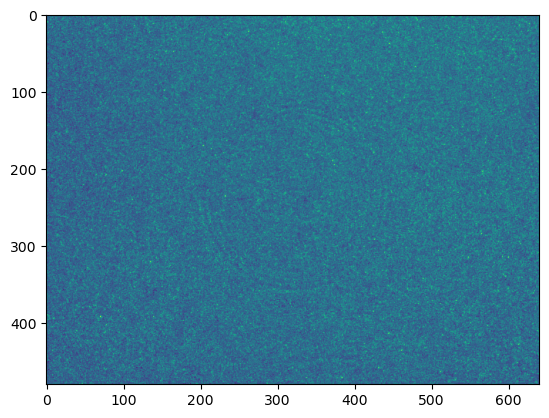

In [8]:
import matplotlib.pyplot as plt
import numpy as np
img = np.array(plt.imread('../Messdaten/20260629_Dusty_Plasma/1_Ringe_0000.bmp')) # 0000 und 0001

fig, ax = plt.subplots()
ax.imshow(img)
#ax.axvline(330, 110, 330, color="k")

def px_to_mm(ax):
    # ax ist in px
    # Paint: 8px = 80 µm
    # Umrechnung: 1px * 10 µm/px
    return ax * 10e-3 # ax in mm

# Auswertung der Videoauswertung

Teilchen= 20.4 Pa, 1. Teilchen
popt= [ 5.01389706 -1.99954156]
StdErr= [0.04799125 0.02880707]
Gasreibungskoeffizient: (26.530164507038748 +/- 0.5048688899536228) 1/s


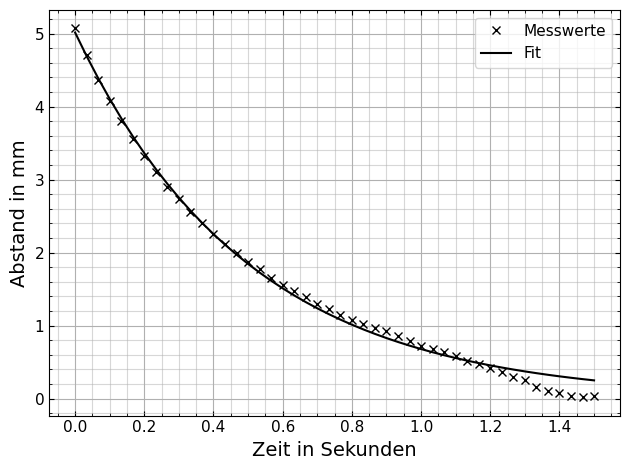

Teilchen= 20.4 Pa, 2. Teilchen
popt= [ 4.6371755  -5.02964374]
StdErr= [0.01350103 0.02247914]
Gasreibungskoeffizient: (14.781825514312652 +/- 0.11482578197586826) 1/s


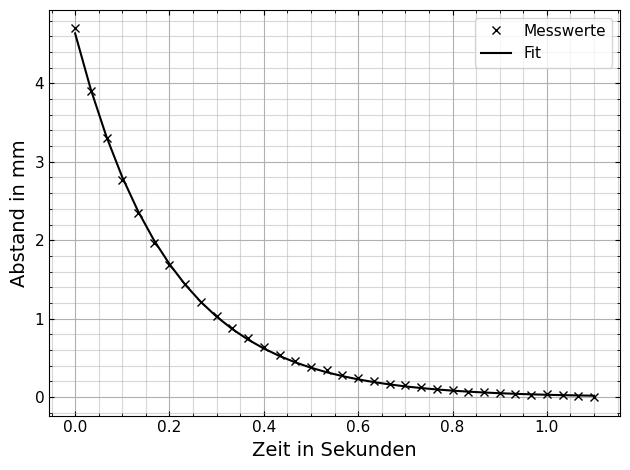

Teilchen= 20.4 Pa, 3. Teilchen
popt= [ 1.89516693 -4.89978716]
StdErr= [0.0056144  0.02223652]
Gasreibungskoeffizient: (14.910426075702071 +/- 0.11772061785651305) 1/s


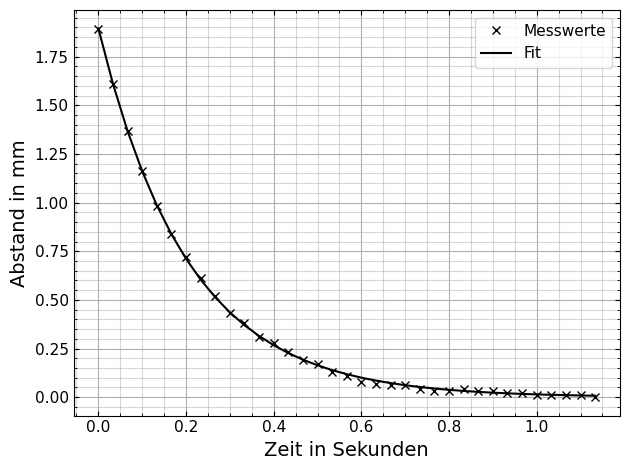

Teilchen= 34 Pa, 1. Teilchen
popt= [ 5.144995   -2.84467454]
StdErr= [0.04459864 0.03147526]
Gasreibungskoeffizient: (20.08742032589185 +/- 0.3084734965980041) 1/s


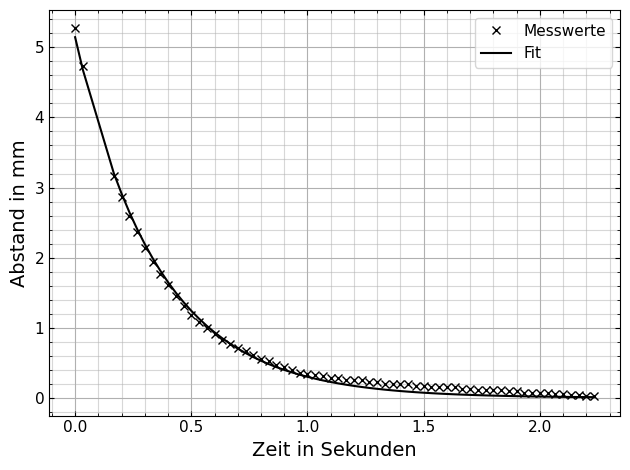

Teilchen= 34 Pa, 2. Teilchen
popt= [ 5.01827955 -3.21700901]
StdErr= [0.02009275 0.0193271 ]
Gasreibungskoeffizient: (18.464090961498556 +/- 0.18716369128609434) 1/s


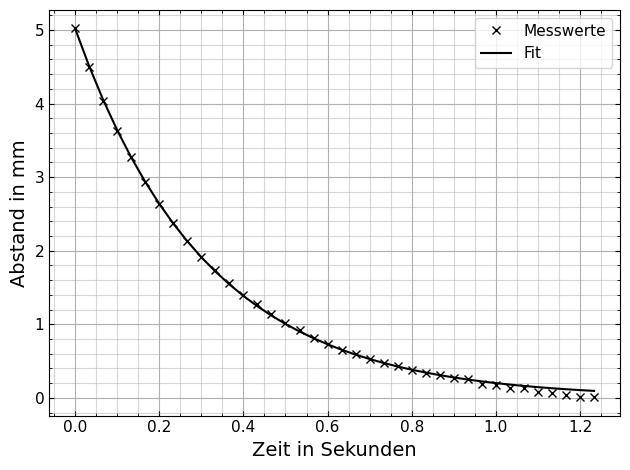

Teilchen= 34 Pa, 3. Teilchen
popt= [ 5.51599142 -3.14561162]
StdErr= [0.01573114 0.01340958]
Gasreibungskoeffizient: (18.73876356902323 +/- 0.15784814098644143) 1/s


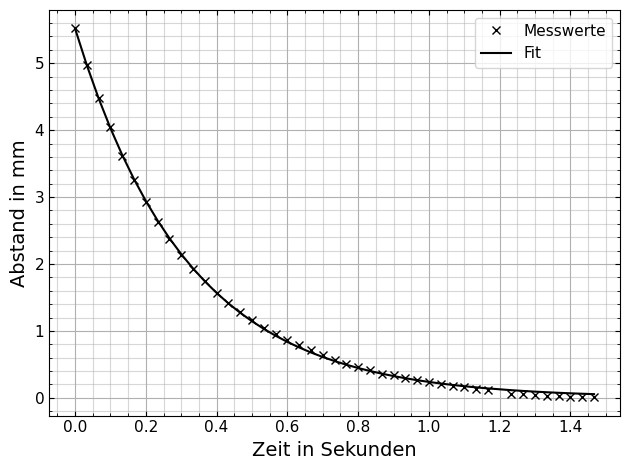

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

def T(frame: np.ndarray):
    """
    Transformiert eine Framenummer zu einer Zeit in Sekunden bei 30 Frames pro Sekunde  
    :frame: Nummer
    """
    fps = 30 # frames per second
    return frame / 30 # seconds

def E(x, a, b):
    return a*np.exp(b*x)

def gamma(alpha):
    Rc = 0.2 # 200mm
    g = 9.81 # m/s²
    return -(g + Rc * alpha**2)/(Rc * alpha)

def gamma_err(a, da, R=0.2, dR=1e-3):
    g = 9.81 # m/s²
    return abs(1+g/(R*a**2)) * da + abs(g/(R**2*a)) * dR

# TODO: Rc Radius der Elektrodenmulde (Kreise vom Anfang)

files = {
    "20.4 Pa, 1. Teilchen":"3_Dynamik_20Pa4_160Vss_0005",
    "20.4 Pa, 2. Teilchen":"3_Dynamik_20Pa4_160Vss_0007",
    "20.4 Pa, 3. Teilchen":"3_Dynamik_20Pa4_160Vss_0008",
    "34 Pa, 1. Teilchen":"3_Dynamik_34Pa_160Vss_0000",
    "34 Pa, 2. Teilchen":"3_Dynamik_34Pa_160Vss_0003",
    "34 Pa, 3. Teilchen":"3_Dynamik_34Pa_160Vss_0005"
}

for plottitle, filename in zip(list(files), list(files.values())):
    frame = np.array([int(fr.split(" ")[-1]) for fr in np.loadtxt(f"../Messdaten/20260629_Dusty_Plasma/{filename}.r", dtype=str, delimiter=":", usecols=0)])# Framenummern der Messpunkte
    t = T(frame) # Umrechnung von Framenummer zu Zeit
    t -= min(t) # t=0 bei erstem Messpunkt
    r = px_to_mm(np.loadtxt(f"../Messdaten/20260629_Dusty_Plasma/{filename}.r", delimiter=":", usecols=1)) # Abstand in mm

    # Fit
    popt, pcov = curve_fit(E, t, r, p0=[1, -1])
    alpha = popt[1]
    dalpha = np.sqrt(np.diag(pcov))[1]

    print("Teilchen=", plottitle)
    print("popt=", popt)
    print("StdErr=",np.sqrt(np.diag(pcov)))
    print(f"Gasreibungskoeffizient: ({gamma(alpha)} +/- {gamma_err(alpha, dalpha)}) 1/s")
    xfit = np.arange(min(t), max(t)+1, 0.001)

    fig, ax = plt.subplots()

    ax.plot(t, r, "xk", label="Messwerte")
    ax.plot(t, E(t, *popt), "-k", label="Fit")

    ax.set_xlabel("Zeit in Sekunden", fontsize=14)
    ax.set_ylabel("Abstand in mm", fontsize=14)

    ax.tick_params(axis="both", which="both", labelsize=11, direction="in", top=True, right=True)

    ax.minorticks_on()
    ax.grid(which="major")
    ax.grid(which="minor", alpha=0.5)
    ax.legend(fontsize=11)
    #ax.set_title(plottitle, fontsize=14)
    fig.tight_layout()
    plt.show()
    #fig.savefig(f"../Bilder/Dusty_Plasma/Exp_Fit_{filename}.pdf")

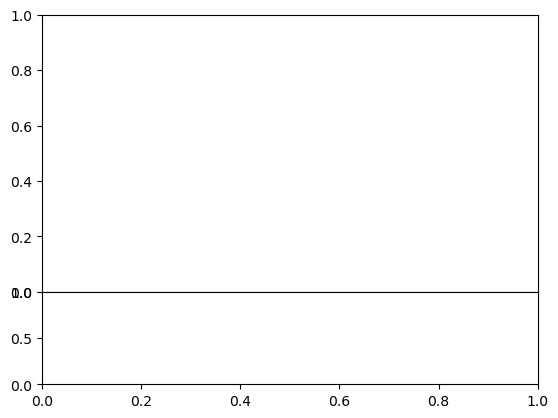

In [10]:
fig, (ax1, ax2) = plt.subplots(2,1,sharex=True, height_ratios= (3,1), gridspec_kw={"hspace":0})